In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score

In [5]:
df=pd.read_csv(r"C:\Users\thohi\Music\CROP_YIELD_FERTILIZER_MANAGEMENT\DATASET\crop_yield.csv")
df

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
...,...,...,...,...,...,...,...,...,...,...
19684,Small millets,1998,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000
19685,Wheat,1998,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000
19686,Maize,1997,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000
19687,Rice,1997,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667


In [6]:
df.shape

(19689, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  object 
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  object 
 3   State            19689 non-null  object 
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), object(3)
memory usage: 1.5+ MB


In [8]:
df.isnull().sum()

Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
dtype: int64

In [9]:
df.describe(include="all")

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689,19689.000000,19689,19689,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
unique,55,NaN,6,30,NaN,NaN,NaN,NaN,NaN,NaN
top,Rice,NaN,Kharif,Karnataka,NaN,NaN,NaN,NaN,NaN,NaN
freq,1197,NaN,8232,1432,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2009.127584,NaN,NaN,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,NaN,6.498099,NaN,NaN,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,NaN,1997.000000,NaN,NaN,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,NaN,2004.000000,NaN,NaN,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,NaN,2010.000000,NaN,NaN,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,NaN,2015.000000,NaN,NaN,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889


In [10]:
df.corr()

C:\Users\thohi\AppData\Local\Temp\ipykernel_12900\1134722465.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
Crop_Year,1.000000,-0.035686,0.003366,-0.011187,0.011169,-0.004657,0.002539
Area,-0.035686,1.000000,0.037441,-0.106054,0.973255,0.973479,0.001858
Production,0.003366,0.037441,1.000000,0.029879,0.039799,0.035171,0.570809
Annual_Rainfall,-0.011187,-0.106054,0.029879,1.000000,-0.109734,-0.097657,0.020761
Fertilizer,0.011169,0.973255,0.039799,-0.109734,1.000000,0.954991,0.002862
Pesticide,-0.004657,0.973479,0.035171,-0.097657,0.954991,1.000000,0.001782
Yield,0.002539,0.001858,0.570809,0.020761,0.002862,0.001782,1.000000


C:\Users\thohi\AppData\Local\Temp\ipykernel_12900\3804867862.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True)


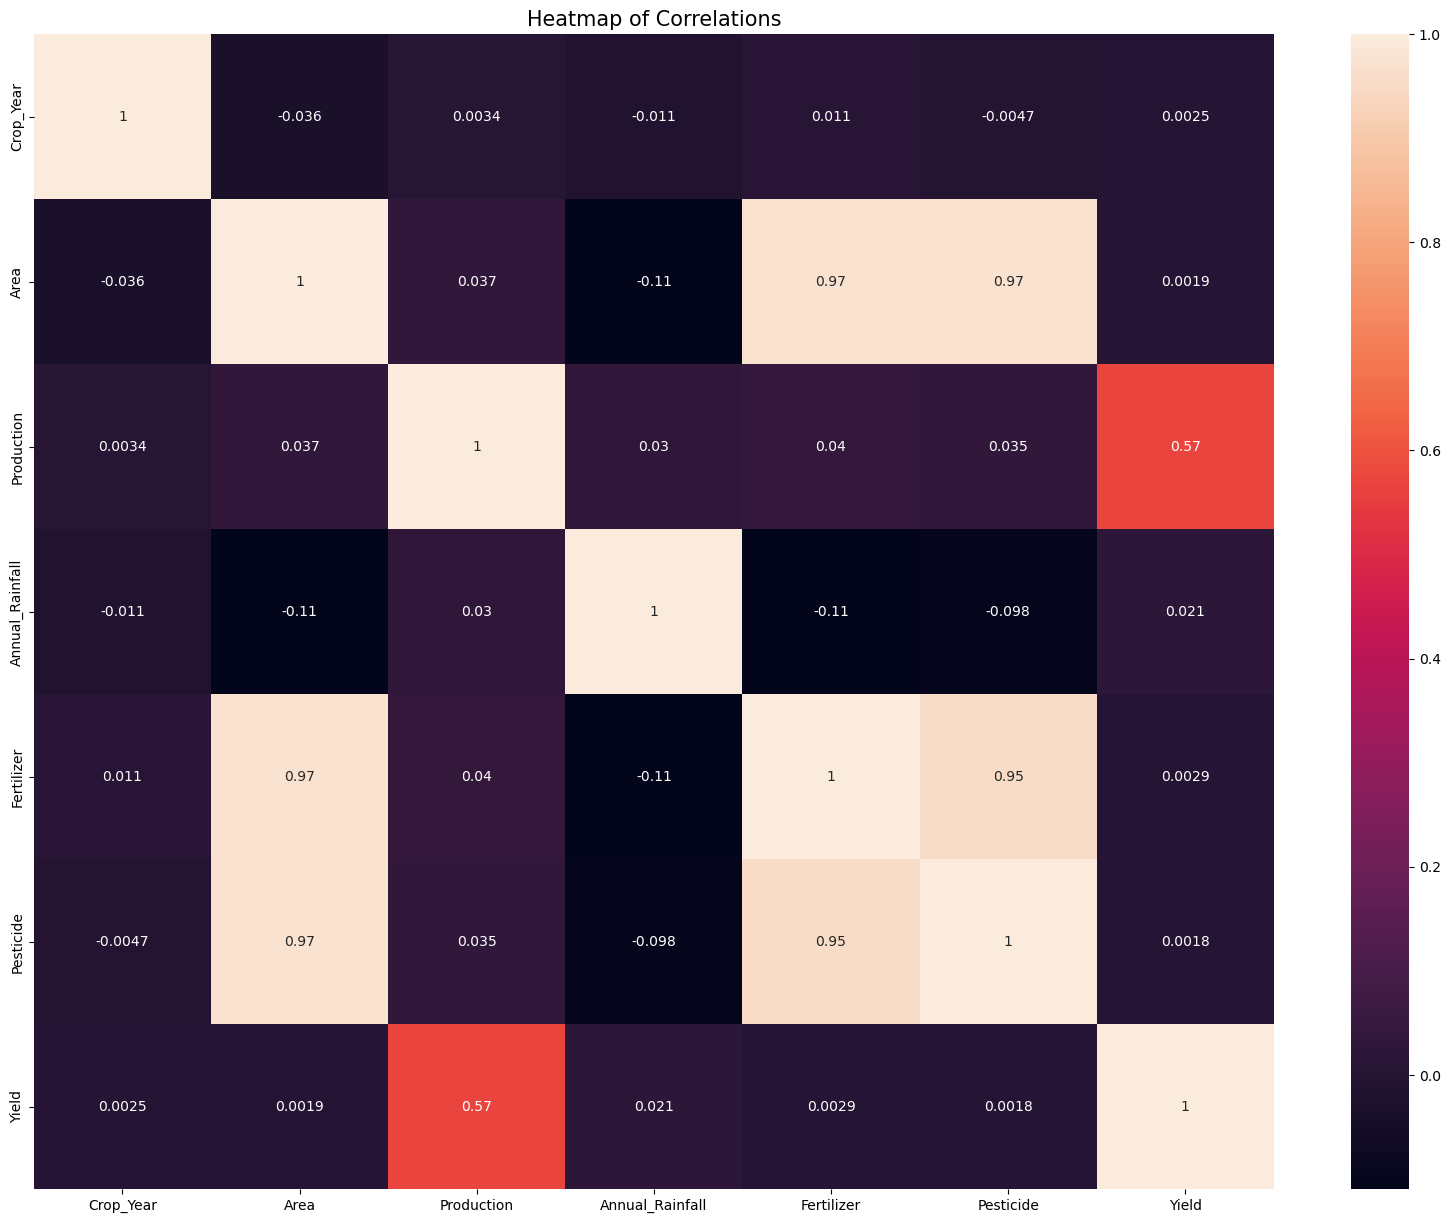

In [11]:
plt.figure(figsize=(20,15))
sns.heatmap(df.corr(),annot=True)
plt.title('Heatmap of Correlations',fontsize=15)
plt.show()

In [12]:
df["Season"].unique()

array(['Whole Year ', 'Kharif     ', 'Rabi       ', 'Autumn     ',
       'Summer     ', 'Winter     '], dtype=object)

In [13]:
df.columns = df.columns.str.strip()

In [14]:
df["Crop"].unique()

array(['Arecanut', 'Arhar/Tur', 'Castor seed', 'Coconut ', 'Cotton(lint)',
       'Dry chillies', 'Gram', 'Jute', 'Linseed', 'Maize', 'Mesta',
       'Niger seed', 'Onion', 'Other  Rabi pulses', 'Potato',
       'Rapeseed &Mustard', 'Rice', 'Sesamum', 'Small millets',
       'Sugarcane', 'Sweet potato', 'Tapioca', 'Tobacco', 'Turmeric',
       'Wheat', 'Bajra', 'Black pepper', 'Cardamom', 'Coriander',
       'Garlic', 'Ginger', 'Groundnut', 'Horse-gram', 'Jowar', 'Ragi',
       'Cashewnut', 'Banana', 'Soyabean', 'Barley', 'Khesari', 'Masoor',
       'Moong(Green Gram)', 'Other Kharif pulses', 'Safflower',
       'Sannhamp', 'Sunflower', 'Urad', 'Peas & beans (Pulses)',
       'other oilseeds', 'Other Cereals', 'Cowpea(Lobia)',
       'Oilseeds total', 'Guar seed', 'Other Summer Pulses', 'Moth'],
      dtype=object)

In [15]:
df["Crop"].value_counts()

Rice                     1197
Maize                     975
Moong(Green Gram)         740
Urad                      733
Groundnut                 725
Sesamum                   685
Potato                    628
Sugarcane                 605
Wheat                     545
Rapeseed &Mustard         528
Bajra                     524
Jowar                     513
Arhar/Tur                 508
Ragi                      498
Gram                      490
Small millets             485
Cotton(lint)              476
Onion                     454
Sunflower                 441
Dry chillies              419
Other Kharif pulses       382
Horse-gram                371
Peas & beans (Pulses)     369
Tobacco                   364
Other  Rabi pulses        355
Soyabean                  349
Turmeric                  337
Masoor                    324
Ginger                    323
Linseed                   308
Castor seed               300
Barley                    297
Sweet potato              273
Garlic    

In [16]:
df["Season"].value_counts()

Kharif         8232
Rabi           5742
Whole Year     3717
Summer         1195
Autumn          414
Winter          389
Name: Season, dtype: int64

In [17]:
df=df.drop(columns=["Crop_Year"])
df

,Crop,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
...,...,...,...,...,...,...,...,...,...
19684,Small millets,Kharif,Nagaland,4000.0,2000,1498.0,395200.00,1160.00,0.500000
19685,Wheat,Rabi,Nagaland,1000.0,3000,1498.0,98800.00,290.00,3.000000
19686,Maize,Kharif,Jammu and Kashmir,310883.0,440900,1356.2,29586735.11,96373.73,1.285000
19687,Rice,Kharif,Jammu and Kashmir,275746.0,5488,1356.2,26242746.82,85481.26,0.016667


In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
le = LabelEncoder()

# List of columns that are of type 'object' (categorical features)
object_cols = df.select_dtypes(include=['object']).columns

# Convert all object-type columns to string (to handle mixed types)
for col in object_cols:
    df[col] = df[col].astype(str)  # Ensure all data in the column is treated as string

# Apply label encoding to each object-type column
for col in object_cols:
    df[col] = le.fit_transform(df[col])

# Check the result (first few rows)
print(df.head())

   Crop  Season  State     Area  Production  Annual_Rainfall  Fertilizer  \
0     0       4      2  73814.0       56708           2051.4  7024878.38   
1     1       1      2   6637.0        4685           2051.4   631643.29   
2     8       1      2    796.0          22           2051.4    75755.32   
3     9       4      2  19656.0   126905000           2051.4  1870661.52   
4    11       1      2   1739.0         794           2051.4   165500.63   

   Pesticide        Yield  
0   22882.34     0.796087  
1    2057.47     0.710435  
2     246.76     0.238333  
3    6093.36  5238.051739  
4     539.09     0.420909  


In [22]:
import xgboost as xgb
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X = df[['Crop', 'Season', 'State', 'Area', 'Annual_Rainfall','Production', 'Pesticide']]
y_yield = df['Yield']  # Target for yield prediction
y_fertilizer = df['Fertilizer']  # Target for fertilizer recommendation

# Split the data into training and testing sets
X_train, X_test, y_train_yield, y_test_yield = train_test_split(X, y_yield, test_size=0.2, random_state=42)
X_train, X_test, y_train_fertilizer, y_test_fertilizer = train_test_split(X, y_fertilizer, test_size=0.2, random_state=42)

# Initialize XGBoost Regressor models
xgb_yield = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
xgb_fertilizer = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# Train the models
xgb_yield.fit(X_train, y_train_yield)
xgb_fertilizer.fit(X_train, y_train_fertilizer)

# Make predictions
y_pred_yield = xgb_yield.predict(X_test)
y_pred_fertilizer = xgb_fertilizer.predict(X_test)

# Saving the model
filename = r'C:\Users\thohi\Music\CROP_YIELD_FERTILIZER_MANAGEMENT\FRONTEND\xgb_yield.pkl'
pickle.dump(xgb_yield, open(filename, 'wb'))
filename = r'C:\Users\thohi\Music\CROP_YIELD_FERTILIZER_MANAGEMENT\FRONTEND\xgb_fertilizer.pkl'
pickle.dump(xgb_fertilizer, open(filename, 'wb'))

# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📌 {model_name} Model Performance:")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

# Print evaluation metrics
evaluate_model(y_test_yield, y_pred_yield, "Crop Yield Prediction")
evaluate_model(y_test_fertilizer, y_pred_fertilizer, "Fertilizer Recommendation")

# Compare Actual vs Recommended Fertilizer Usage
df_test = X_test.copy()
df_test["Actual_Fertilizer"] = y_test_fertilizer.values
df_test["Recommended_Fertilizer"] = y_pred_fertilizer

# Function to check fertilizer usage efficiency
def check_fertilizer_usage(row):
    actual = row["Actual_Fertilizer"]
    recommended = row["Recommended_Fertilizer"]
    if actual > recommended * 1.2:  # If actual is 20% more than recommended
        return "Overuse"
    elif actual < recommended * 0.8:  # If actual is 20% less than recommended
        return "Underuse"
    else:
        return "Optimal Use"

# Apply function to determine fertilizer efficiency
df_test["Fertilizer_Usage_Efficiency"] = df_test.apply(check_fertilizer_usage, axis=1)

# Display the first few results
print(df_test[["Actual_Fertilizer", "Recommended_Fertilizer", "Fertilizer_Usage_Efficiency"]].head())


📌 Crop Yield Prediction Model Performance:
R² Score: 0.8630
Mean Absolute Error (MAE): 15.4292
Root Mean Squared Error (RMSE): 331.3489

📌 Fertilizer Recommendation Model Performance:
R² Score: 0.9710
Mean Absolute Error (MAE): 2940692.4714
Root Mean Squared Error (RMSE): 14636924.3218
       Actual_Fertilizer  Recommended_Fertilizer Fertilizer_Usage_Efficiency
18238          32182.500            2.245418e+05                    Underuse
6918          877695.100            1.018456e+06                 Optimal Use
4894          971758.250            9.092074e+05                 Optimal Use
10960        4258119.139            4.029492e+06                 Optimal Use
15615        1409088.000            1.047118e+06                     Overuse


In [23]:
# Example Prediction
sample_input = np.array([[0, 4, 2, 73814.0, 56708, 2051.4, 22882.34]])  # Modify as per dataset structure
predicted_yield = xgb_yield.predict(sample_input)[0]
recommended_fertilizer = xgb_fertilizer.predict(sample_input)[0]

print(f"Predicted Crop Yield: {predicted_yield:.2f} tons")
print(f"Recommended Fertilizer Usage: {recommended_fertilizer:.2f} kg")

# Check fertilizer recommendation category
actual_fertilizer_used = 55  # Example actual usage input (user can change this)
if actual_fertilizer_used > recommended_fertilizer * 1.2:
    usage_status = "Overuse"
elif actual_fertilizer_used < recommended_fertilizer * 0.8:
    usage_status = "Underuse"
else:
    usage_status = "Optimal Use"

print(f"Fertilizer Usage Status: {usage_status}")

Predicted Crop Yield: -2.98 tons
Recommended Fertilizer Usage: 9903476.00 kg
Fertilizer Usage Status: Underuse


In [27]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize Random Forest Regressor models
rf_yield = RandomForestRegressor(n_estimators=100, random_state=42)
rf_fertilizer = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the models
rf_yield.fit(X_train, y_train_yield)
rf_fertilizer.fit(X_train, y_train_fertilizer)

# Make predictions
y_pred_yield = rf_yield.predict(X_test)
y_pred_fertilizer = rf_fertilizer.predict(X_test)

# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📌 {model_name} Model Performance:")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

# Print evaluation metrics
evaluate_model(y_test_yield, y_pred_yield, "Crop Yield Prediction (Random Forest)")
evaluate_model(y_test_fertilizer, y_pred_fertilizer, "Fertilizer Recommendation (Random Forest)")

# ========================= Sample Prediction ========================= #
sample_input = np.array([[2, 1, 10, 100, 900, 5]])  # Modify as per dataset structure
predicted_yield = rf_yield.predict(sample_input)[0]
recommended_fertilizer = rf_fertilizer.predict(sample_input)[0]

print(f"Predicted Crop Yield: {predicted_yield:.2f} tons")
print(f"Recommended Fertilizer Usage: {recommended_fertilizer:.2f} kg")

# Check fertilizer recommendation category
actual_fertilizer_used = 55  # Example actual usage input
if actual_fertilizer_used > recommended_fertilizer * 1.2:
    usage_status = "Overuse"
elif actual_fertilizer_used < recommended_fertilizer * 0.8:
    usage_status = "Underuse"
else:
    usage_status = "Optimal Use"

print(f"Fertilizer Usage Status: {usage_status}")



📌 Crop Yield Prediction (Random Forest) Model Performance:
R² Score: 0.9730
Mean Absolute Error (MAE): 9.9626
Root Mean Squared Error (RMSE): 147.1582

📌 Fertilizer Recommendation (Random Forest) Model Performance:
R² Score: 0.9807
Mean Absolute Error (MAE): 2390138.2241
Root Mean Squared Error (RMSE): 11940936.0892
Predicted Crop Yield: 0.61 tons
Recommended Fertilizer Usage: 13034.28 kg
Fertilizer Usage Status: Underuse


C:\Users\thohi\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\thohi\anaconda3\lib\site-packages\sklearn\base.py:420: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [31]:
# Import necessary libraries
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to create a simple neural network
def create_nn_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)  # Output layer
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Initialize and train models
nn_yield = create_nn_model()
nn_fertilizer = create_nn_model()

# Train the models
nn_yield.fit(X_train, y_train_yield, epochs=50, batch_size=16, validation_data=(X_test, y_test_yield), verbose=1)
nn_fertilizer.fit(X_train, y_train_fertilizer, epochs=50, batch_size=16, validation_data=(X_test, y_test_fertilizer), verbose=1)

# Make predictions
y_pred_yield = nn_yield.predict(X_test)
y_pred_fertilizer = nn_fertilizer.predict(X_test)

# Evaluate the models
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n📌 {model_name} Model Performance:")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"Root Mean Squared Error (RMSE): {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")

evaluate_model(y_test_yield, y_pred_yield, "Crop Yield Prediction (Neural Network)")
evaluate_model(y_test_fertilizer, y_pred_fertilizer, "Fertilizer Recommendation (Neural Network)")

# ========================= Sample Prediction ========================= #
sample_input = np.array([[2, 1, 10, 100, 900, 5]])  # Modify as per dataset structure
sample_input_scaled = scaler.transform(sample_input)

predicted_yield = nn_yield.predict(sample_input_scaled)[0][0]
recommended_fertilizer = nn_fertilizer.predict(sample_input_scaled)[0][0]

print(f"\n🌾 Predicted Crop Yield: {predicted_yield:.2f} tons")
print(f"🧪 Recommended Fertilizer Usage: {recommended_fertilizer:.2f} kg")

# Check fertilizer recommendation category
actual_fertilizer_used = 55  # Example actual usage input
if actual_fertilizer_used > recommended_fertilizer * 1.2:
    usage_status = "Overuse"
elif actual_fertilizer_used < recommended_fertilizer * 0.8:
    usage_status = "Underuse"
else:
    usage_status = "Optimal Use"

print(f"🔍 Fertilizer Usage Status: {usage_status}")

ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.10 from "C:\Users\thohi\anaconda3\python.exe"
  * The NumPy version is: "1.23.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.10 from "C:\Users\thohi\anaconda3\python.exe"
  * The NumPy version is: "1.23.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: 

IMPORTANT: PLEASE READ THIS FOR ADVICE ON HOW TO SOLVE THIS ISSUE!

Importing the numpy C-extensions failed. This error can happen for
many reasons, often due to issues with your setup or how NumPy was
installed.

We have compiled some common reasons and troubleshooting tips at:

    https://numpy.org/devdocs/user/troubleshooting-importerror.html

Please note and check the following:

  * The Python version is: Python3.10 from "C:\Users\thohi\anaconda3\python.exe"
  * The NumPy version is: "1.23.5"

and make sure that they are the versions you expect.
Please carefully study the documentation linked above for further help.

Original error was: DLL load failed while importing _multiarray_umath: The specified module could not be found.


ImportError: _multiarray_umath failed to import

ImportError: numpy._core.umath failed to import

In [30]:
!pip install tensorflow

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
scipy 1.10.0 requires numpy<1.27.0,>=1.19.5, but you have numpy 2.0.2 which is incompatible.
numba 0.56.4 requires numpy<1.24,>=1.18, but you have numpy 2.0.2 which is incompatible.



     -------------------------------------- 390.0/390.0 MB 2.1 MB/s eta 0:00:00
     ---------------------------------------- 57.5/57.5 kB 3.1 MB/s eta 0:00:00
     ---------------------------------------- 26.4/26.4 MB 6.7 MB/s eta 0:00:00
     -------------------------------------- 126.6/126.6 kB 7.8 MB/s eta 0:00:00
     ---------------------------------------- 15.9/15.9 MB 6.8 MB/s eta 0:00:00
     ---------------------------------------- 3.0/3.0 MB 7.0 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 7.3 MB/s eta 0:00:00
     -------------------------------------- 434.5/434.5 kB 9.0 MB/s eta 0:00:00
     ---------------------------------------- 1.3/1.3 MB 6.9 MB/s eta 0:00:00
     ---------------------------------------- 71.9/71.9 kB 2.0 MB/s eta 0:00:00
     -------------------------------------- 133.7/133.7 kB 7.7 MB/s eta 0:00:00
     ---------------------------------------- 4.3/4.3 MB 6.7 MB/s eta 0:00:00
     ---------------------------------------- 5